# Color-correlated decoding: saved-run analysis

This notebook reads an existing canonical YAML run. It does not run a simulation. Set `run_path`, `filter`, and `group_by` below. The first `group_by` field controls line color; the second controls marker shape. Up to two fields are supported. The boxed legend occupies its own top region, while the main plotting area has a fixed physical size. Confidence bands are 99% Wilson intervals.

In [1]:
from pathlib import Path
import sys
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from color_code_softoutput.analysis.color_correlated import ColorCorrelatedRun

# Edit this path to select a completed run.
run_path = PROJECT_ROOT / "results/26_09_27_13_35_36_2046ab4b"
run = ColorCorrelatedRun(run_path)
print("Run:", run.run_directory)
print("Start:", run.run_log["simulation_start_time"])
print("End:", run.run_log["simulation_end_time"])
print("Planned points:", len(run.catalog))
print("logical_error files present:", int(run.catalog["data_available"].sum()), "/", len(run.catalog))

Run: /home/quantum_teresheys/workspace/color_code_softoutput/results/26_09_27_13_35_36_2046ab4b
Start: 2026-09-27T13:35:36.718082+09:00
End: 2026-09-27T13:41:06.763655+09:00
Planned points: 36
logical_error files present: 36 / 36


## Confirm the configuration and available points

`run_log.json` supplies the saved configuration. The catalog lists every planned point and whether its `logical_error.parquet` is present. Aggregation also validates metric schemas, row counts, and shot indices.

In [2]:
display(run.run_log["config"])
display(run.catalog)

{'simulation': {'output_root': '/home/quantum_teresheys/workspace/color_code_softoutput/results',
  'shots': 10000,
  'workers': 4,
  'master_seed': 20260927,
  'buffer_shots': 100,
  'verbose': True},
 'chunking': {'calibration_shots': 4,
  'target_chunk_seconds': 1.0,
  'min_chunk_shots': 1,
  'max_chunk_shots': 100,
  'throughput_ema_alpha': 0.5},
 'sweep': {'distance': [3, 5, 7],
  'physical_error_rate': [0.1, 0.08, 0.06, 0.04, 0.02, 0.01],
  'noise_model': ['depol'],
  'rounds': [1],
  'circuit_type': ['tri'],
  'cnot_schedule': ['tri_optimal']},
 'color_code_options': {'temp_bdry_type': 'Z'},
 'decoders': [{'type': 'concat_mwpm', 'options': {}, 'decode_options': {}},
  {'type': 'color_correlated',
   'options': {'enable_colorcorrelated_decoding': True},
   'decode_options': {}}]}

,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,expected_shots,point_directory,data_available
0,concat_mwpm,tri,3,1,0.10,depol,tri_optimal,10000,"decoder_type=concat_mwpm,circuit_type=tri,d=3,...",True
1,color_correlated,tri,3,1,0.10,depol,tri_optimal,10000,"decoder_type=color_correlated,circuit_type=tri...",True
2,concat_mwpm,tri,3,1,0.08,depol,tri_optimal,10000,"decoder_type=concat_mwpm,circuit_type=tri,d=3,...",True
3,color_correlated,tri,3,1,0.08,depol,tri_optimal,10000,"decoder_type=color_correlated,circuit_type=tri...",True
4,concat_mwpm,tri,3,1,0.06,depol,tri_optimal,10000,"decoder_type=concat_mwpm,circuit_type=tri,d=3,...",True
5,color_correlated,tri,3,1,0.06,depol,tri_optimal,10000,"decoder_type=color_correlated,circuit_type=tri...",True
6,concat_mwpm,tri,3,1,0.04,depol,tri_optimal,10000,"decoder_type=concat_mwpm,circuit_type=tri,d=3,...",True
7,color_correlated,tri,3,1,0.04,depol,tri_optimal,10000,"decoder_type=color_correlated,circuit_type=tri...",True
8,concat_mwpm,tri,3,1,0.02,depol,tri_optimal,10000,"decoder_type=concat_mwpm,circuit_type=tri,d=3,...",True
9,color_correlated,tri,3,1,0.02,depol,tri_optimal,10000,"decoder_type=color_correlated,circuit_type=tri...",True


## Choose conditions and line styles

Use scalar or list values in `filter`, for example `{"distance": [3, 5], "noise_model": "depol"}`. Available fields are `decoder_type`, `circuit_type`, `distance`, `rounds`, `physical_error_rate`, `noise_model`, and `cnot_schedule`. Omitted filters include all values. Set `baseline_compare=True` to add `decoder_type=baseline` from each selected color-correlated point’s `default_logical_error.parquet`. This baseline uses the same shots as that point’s `logical_error.parquet`; `concat_mwpm` points are separate runs. Include `decoder_type` in `group_by` when comparing the baseline. Every parameter that varies in the selected points (except physical error rate) must appear in `group_by` or be fixed by `filter`.

In [3]:
filter = {
    # "distance": [3, 5],
    # "decoder_type": ["concat_mwpm", "color_correlated"],
}
group_by = ["distance", "decoder_type"]  # first: color; second: marker
baseline_compare = True  # add the paired default decoder as decoder_type=baseline
yscale = "log"  # "log" or "linear"
plot_width = 7.4  # inches; independent of legend size
plot_height = 4.6  # inches; independent of legend size
legend_fontsize = 9
legend_row_height = 0.48  # inches per first-group value
save_figure = True

print("Selected points:")
display(run.select(filter))

Selected points:


,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,expected_shots,point_directory,data_available
0,concat_mwpm,tri,3,1,0.10,depol,tri_optimal,10000,"decoder_type=concat_mwpm,circuit_type=tri,d=3,...",True
1,color_correlated,tri,3,1,0.10,depol,tri_optimal,10000,"decoder_type=color_correlated,circuit_type=tri...",True
2,concat_mwpm,tri,3,1,0.08,depol,tri_optimal,10000,"decoder_type=concat_mwpm,circuit_type=tri,d=3,...",True
3,color_correlated,tri,3,1,0.08,depol,tri_optimal,10000,"decoder_type=color_correlated,circuit_type=tri...",True
4,concat_mwpm,tri,3,1,0.06,depol,tri_optimal,10000,"decoder_type=concat_mwpm,circuit_type=tri,d=3,...",True
5,color_correlated,tri,3,1,0.06,depol,tri_optimal,10000,"decoder_type=color_correlated,circuit_type=tri...",True
6,concat_mwpm,tri,3,1,0.04,depol,tri_optimal,10000,"decoder_type=concat_mwpm,circuit_type=tri,d=3,...",True
7,color_correlated,tri,3,1,0.04,depol,tri_optimal,10000,"decoder_type=color_correlated,circuit_type=tri...",True
8,concat_mwpm,tri,3,1,0.02,depol,tri_optimal,10000,"decoder_type=concat_mwpm,circuit_type=tri,d=3,...",True
9,color_correlated,tri,3,1,0.02,depol,tri_optimal,10000,"decoder_type=color_correlated,circuit_type=tri...",True


## Logical error rate versus physical error rate

The returned table includes shots, failures, LER, and 99% Wilson bounds for every plotted point. With baseline comparison enabled, `metric` identifies which saved file supplies each curve and `source_decoder_type` identifies the source experiment.
On a log axis, a zero-failure point is displayed at 0.5/shots so it remains visible. The numeric table keeps the measured LER of zero.

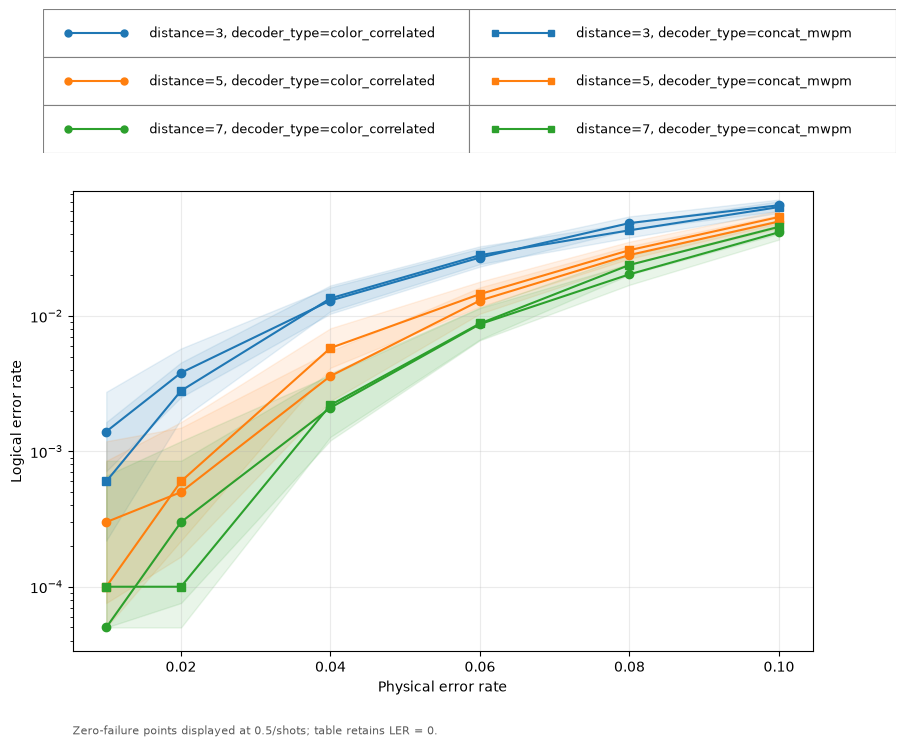

,distance,decoder_type,physical_error_rate,shots,failures,logical_error_rate,ler_low,ler_high
0,3,color_correlated,0.01,10000,14,0.0014,0.000713,0.002749
1,3,concat_mwpm,0.01,10000,6,0.0006,0.000219,0.001643
2,3,color_correlated,0.02,10000,38,0.0038,0.002511,0.005747
3,3,concat_mwpm,0.02,10000,28,0.0028,0.001730,0.004530
4,3,color_correlated,0.04,10000,130,0.0130,0.010388,0.016258
5,3,concat_mwpm,0.04,10000,135,0.0135,0.010834,0.016812
6,3,color_correlated,0.06,10000,270,0.0270,0.023128,0.031499
7,3,concat_mwpm,0.06,10000,281,0.0281,0.024146,0.032680
8,3,color_correlated,0.08,10000,485,0.0485,0.043260,0.054339
9,3,concat_mwpm,0.08,10000,429,0.0429,0.037977,0.048430


Saved figure: /home/quantum_teresheys/workspace/color_code_softoutput/results/26_09_27_13_35_36_2046ab4b/analysis/color_correlated_ler.png


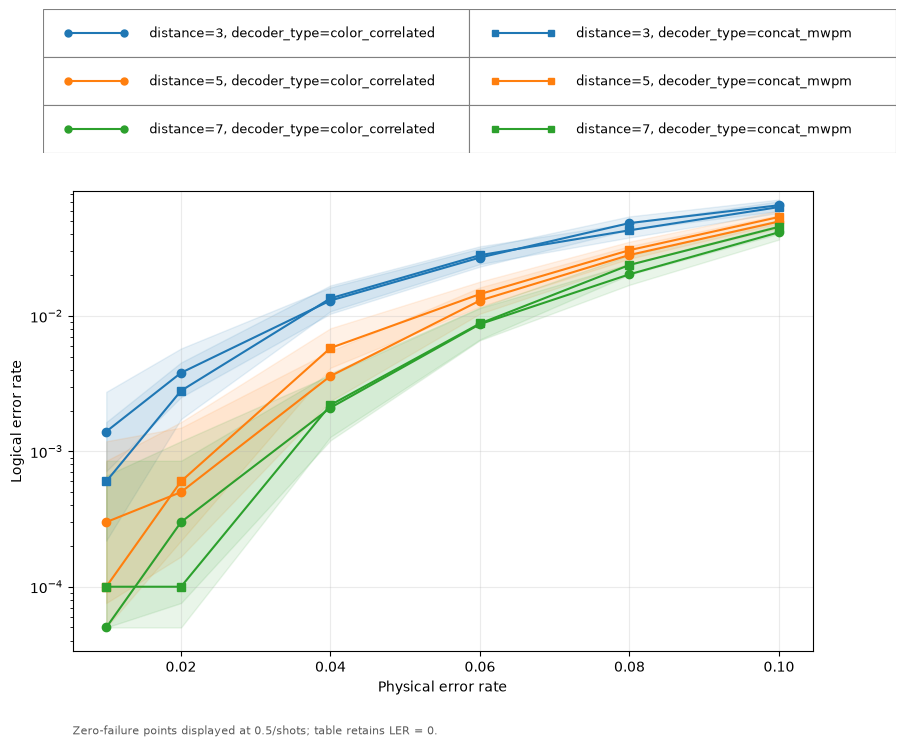

In [4]:
figure, axes, ler_table = run.plot_ler(
    filter=filter,
    group_by=group_by,
    baseline_compare=baseline_compare,
    yscale=yscale,
    plot_width=plot_width,
    plot_height=plot_height,
    legend_fontsize=legend_fontsize,
    legend_row_height=legend_row_height,
)
display(figure)
columns = ["distance", "decoder_type", "physical_error_rate", "shots", "failures", "logical_error_rate", "ler_low", "ler_high"]
if baseline_compare:
    columns[2:2] = ["source_decoder_type", "metric"]
display(ler_table[columns])
if save_figure:
    output_dir = run.run_directory / "analysis"
    output_dir.mkdir(exist_ok=True)
    figure_name = "color_correlated_ler_with_baseline.png" if baseline_compare else "color_correlated_ler.png"
    figure_path = output_dir / figure_name
    figure.savefig(figure_path, dpi=180, bbox_inches="tight")
    print("Saved figure:", figure_path)

## Correlated-decoding counts by experiment condition

The two count columns are blank for ordinary decoder points because those flag files are not produced. `shots` is the denominator for each count.

In [5]:
count_table = run.count_table(filter=filter)
display(count_table)

,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,shots,better_weight_count,effect_count
0,color_correlated,tri,3,1,0.01,depol,tri_optimal,10000,0,0
1,concat_mwpm,tri,3,1,0.01,depol,tri_optimal,10000,<NA>,<NA>
2,color_correlated,tri,3,1,0.02,depol,tri_optimal,10000,0,0
3,concat_mwpm,tri,3,1,0.02,depol,tri_optimal,10000,<NA>,<NA>
4,color_correlated,tri,3,1,0.04,depol,tri_optimal,10000,0,0
5,concat_mwpm,tri,3,1,0.04,depol,tri_optimal,10000,<NA>,<NA>
6,color_correlated,tri,3,1,0.06,depol,tri_optimal,10000,0,0
7,concat_mwpm,tri,3,1,0.06,depol,tri_optimal,10000,<NA>,<NA>
8,color_correlated,tri,3,1,0.08,depol,tri_optimal,10000,0,0
9,concat_mwpm,tri,3,1,0.08,depol,tri_optimal,10000,<NA>,<NA>
